In [1]:
# Auto-reload for development
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import torch
from nowcast_lstm.LSTM import LSTM

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

## Configuration

In [2]:
# Data paths
data_path = "../data/data_tf.csv"
metadata_path = "../data/meta_data.csv"

# Configuration
target_variable = "gdpc1"
lags = list(range(-2, 3))
train_start_date = "1947-01-01"
test_start_date = "2005-03-01"
test_end_date = "2010-03-01"

# LSTM hyperparameters
lstm_config = {
    "n_timesteps": 6,
    "fill_na_func": np.nanmean,
    "fill_ragged_edges_func": np.nanmean,
    "n_models": 10,
    "train_episodes": 100,
    "batch_size": 50,
    "decay": 0.98,
    "n_hidden": 10,
    "n_layers": 1,
    "dropout": 0.0,
    "criterion": torch.nn.MSELoss(),
    "optimizer": torch.optim.Adam,
    "optimizer_parameters": {"lr": 1e-2, "weight_decay": 0.0}
}

## Load Data

In [3]:
# Load data
data = pd.read_csv(data_path, parse_dates=["date"])
metadata = pd.read_csv(metadata_path)

# Test dataset
test = data.loc[
    (data.date >= train_start_date) & (data.date <= test_end_date), :
].reset_index(drop=True)

print(f"Data shape: {test.shape}")
print(f"Date range: {test.date.min()} to {test.date.max()}")
test.tail()

Data shape: (759, 25)
Date range: 1947-01-01 00:00:00 to 2010-03-01 00:00:00


,date,payems,gdpc1,cpiaucsl,dgorder,hsn1f,rsafs,unrate,houst,indpro,...,ir,cpilfesl,pcepilfe,pcepi,permit,tcu,businv,ulcnfb,iq,a261rx1q020sbea
754,2009-11-01,0.000092,NaN,0.003349,-0.004209,-0.053030,0.007964,-0.010000,0.101124,0.004176,...,0.014718,0.000748,0.000886,0.002499,0.068611,0.005640,0.007865,NaN,0.008482,NaN
755,2009-12-01,-0.002068,0.010680,0.000520,0.000630,-0.061333,0.004928,0.000000,-0.011905,0.003610,...,0.002417,0.000974,0.000854,0.000589,0.065811,0.005312,-0.001848,-0.008605,0.006728,0.015073
756,2010-01-01,0.000015,NaN,0.000649,0.127685,-0.019886,-0.000084,-0.010101,0.056799,0.010901,...,0.012058,-0.001123,0.001468,0.002186,-0.042169,0.012825,0.001697,NaN,0.008354,NaN
757,2010-02-01,-0.000709,NaN,-0.000952,-0.003127,-0.026087,0.002289,0.000000,-0.016287,0.003535,...,-0.000794,0.000444,0.000873,-0.000031,0.022013,0.005553,0.006595,NaN,-0.003314,NaN
758,2010-03-01,0.001396,0.005001,0.000331,0.009410,0.133929,0.021696,0.010204,0.052980,0.007105,...,0.003975,0.000236,0.001496,0.001416,0.056923,0.009229,0.004449,-0.011910,0.007481,0.005757


## Helper Function for Vintage Data

In [4]:
def gen_lagged_data(metadata, data, last_date, lag):
    """Generate lagged datasets for testing on vintages."""
    lagged_data = data.loc[data.date <= last_date, :].reset_index(drop=True)
    for col in lagged_data.columns[1:]:
        pub_lag = metadata.loc[metadata.series == col, "months_lag"].values[0]
        lagged_data.loc[
            (len(lagged_data) - pub_lag + lag - 1):, col
        ] = np.nan
    return lagged_data

## Prepare Test Dates and Actuals

In [5]:
# Test dates
dates = pd.date_range(
    test_start_date, test_end_date, freq="3MS"
).strftime("%Y-%m-%d").tolist()

# Actual values
actuals = list(test.loc[test.date.isin(dates), target_variable].values)

print(f"Testing on {len(dates)} dates from {dates[0]} to {dates[-1]}")
print(f"Actual values: {len(actuals)}")

Testing on 21 dates from 2005-03-01 to 2010-03-01
Actual values: 21


## Train and Predict on Vintages

In [6]:
# Store predictions by lag
pred_dict = {k: [] for k in lags}

for date in dates:
    print(f"Processing {date}...", end=" ")
    
    # Training data (up to 3 months before prediction date)
    train_cutoff = str(pd.to_datetime(date) - pd.tseries.offsets.DateOffset(months=3))[:10]
    train = test.loc[test.date <= train_cutoff, :]
    
    # Train LSTM model
    model = LSTM(data=train, target_variable=target_variable, **lstm_config)
    model.train(quiet=True)
    
    # Get predictions for each vintage
    for lag in lags:
        tmp_data = gen_lagged_data(metadata, test, date, lag)
        pred = model.predict(tmp_data).loc[
            lambda x: x.date == date, "predictions"
        ].values[0]
        pred_dict[lag].append(pred)
    
    print("✓")

print(f"\nCompleted predictions for {len(dates)} dates across {len(lags)} vintages")

Processing 2005-03-01... ✓
Processing 2005-06-01... ✓
Processing 2005-06-01... ✓
Processing 2005-09-01... ✓
Processing 2005-09-01... ✓
Processing 2005-12-01... ✓
Processing 2005-12-01... ✓
Processing 2006-03-01... ✓
Processing 2006-03-01... ✓
Processing 2006-06-01... ✓
Processing 2006-06-01... ✓
Processing 2006-09-01... ✓
Processing 2006-09-01... ✓
Processing 2006-12-01... ✓
Processing 2006-12-01... ✓
Processing 2007-03-01... ✓
Processing 2007-03-01... ✓
Processing 2007-06-01... ✓
Processing 2007-06-01... ✓
Processing 2007-09-01... ✓
Processing 2007-09-01... ✓
Processing 2007-12-01... ✓
Processing 2007-12-01... ✓
Processing 2008-03-01... ✓
Processing 2008-03-01... ✓
Processing 2008-06-01... ✓
Processing 2008-06-01... ✓
Processing 2008-09-01... ✓
Processing 2008-09-01... ✓
Processing 2008-12-01... ✓
Processing 2008-12-01... ✓
Processing 2009-03-01... ✓
Processing 2009-03-01... ✓
Processing 2009-06-01... ✓
Processing 2009-06-01... ✓
Processing 2009-09-01... ✓
Processing 2009-09-01... ✓
P

## Evaluate Performance

In [7]:
# Calculate RMSE by vintage
performance = pd.DataFrame(columns=["Vintage", "RMSE"])
for lag in lags:
    rmse = np.sqrt(np.mean((np.array(actuals) - np.array(pred_dict[lag])) ** 2))
    tmp = pd.DataFrame({"Vintage": lag, "RMSE": rmse}, index=[0])
    performance = pd.concat([performance, tmp]).reset_index(drop=True)

print("Performance by Vintage:")
performance.round(4)

Performance by Vintage:


,Vintage,RMSE
0,-2,0.0071
1,-1,0.0051
2,0,0.0044
3,1,0.0040
4,2,0.0040


## Visualize Predictions

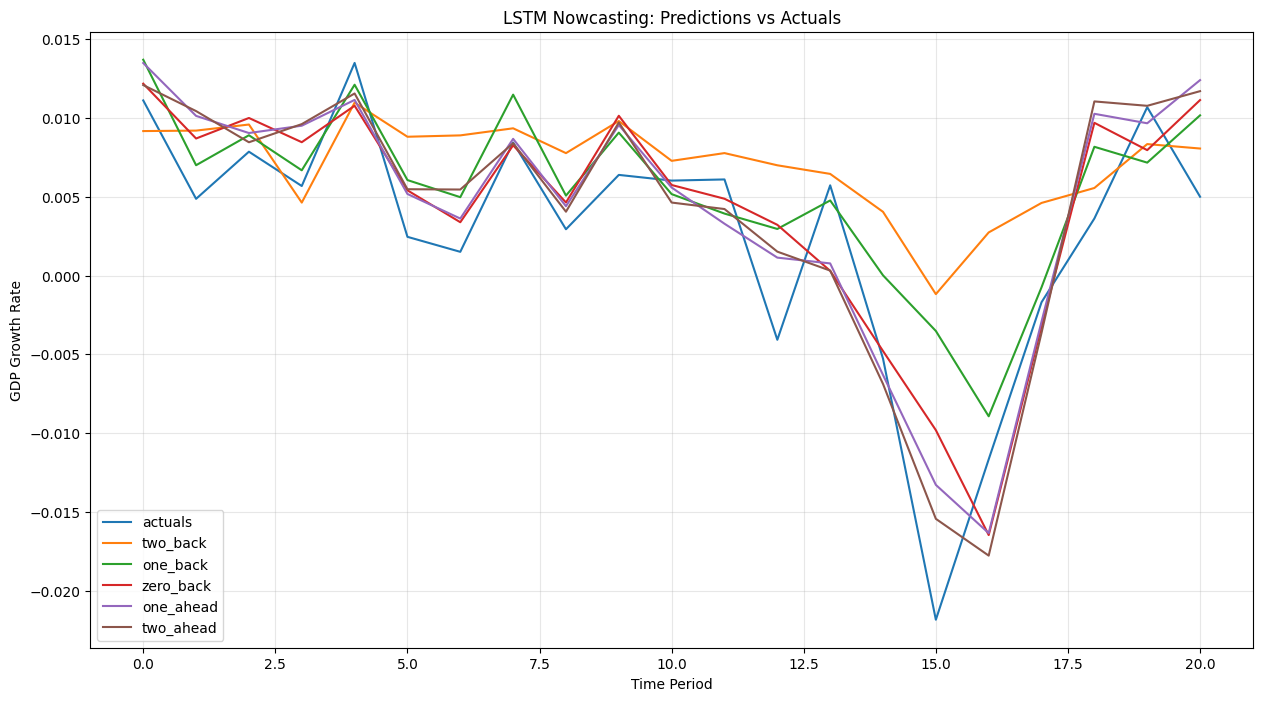

In [8]:
# Plot predictions vs actuals
pd.DataFrame({
    "actuals": actuals,
    "two_back": pred_dict[-2],
    "one_back": pred_dict[-1],
    "zero_back": pred_dict[0],
    "one_ahead": pred_dict[1],
    "two_ahead": pred_dict[2]
}).plot(title="LSTM Nowcasting: Predictions vs Actuals", figsize=(15, 8))
plt.ylabel("GDP Growth Rate")
plt.xlabel("Time Period")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Inference on New Data

Example of using the trained model to predict a future date.

In [9]:
# Prepare data for new prediction
new_data = test.copy()
desired_date = pd.to_datetime("2010-06-01")

# Add future dates if needed
while desired_date > np.max(new_data.date):
    new_data.loc[len(new_data), "date"] = np.max(new_data.date) + pd.DateOffset(months=1)

print(f"Predicting for: {desired_date}")
print(f"Latest date in data: {new_data.date.max()}")
new_data.tail()

Predicting for: 2010-06-01 00:00:00
Latest date in data: 2010-06-01 00:00:00


,date,payems,gdpc1,cpiaucsl,dgorder,hsn1f,rsafs,unrate,houst,indpro,...,ir,cpilfesl,pcepilfe,pcepi,permit,tcu,businv,ulcnfb,iq,a261rx1q020sbea
757,2010-02-01,-0.000709,NaN,-0.000952,-0.003127,-0.026087,0.002289,0.000000,-0.016287,0.003535,...,-0.000794,0.000444,0.000873,-0.000031,0.022013,0.005553,0.006595,NaN,-0.003314,NaN
758,2010-03-01,0.001396,0.005001,0.000331,0.009410,0.133929,0.021696,0.010204,0.052980,0.007105,...,0.003975,0.000236,0.001496,0.001416,0.056923,0.009229,0.004449,-0.01191,0.007481,0.005757
759,2010-04-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
760,2010-05-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
761,2010-06-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Train final model and predict
final_model = LSTM(data=new_data, target_variable=target_variable, **lstm_config)
final_model.train(quiet=True)

prediction = final_model.predict(new_data).loc[
    lambda x: x.date == "2010-06-01", "predictions"
].values[0]

print(f"\nPrediction for {desired_date.strftime('%Y-%m-%d')}: {prediction:.4f}")


Prediction for 2010-06-01: 0.0087


## Summary

This notebook demonstrates GDP nowcasting using an LSTM neural network. The model uses a rolling window approach with 6 timesteps and an ensemble of 10 models for robustness. The LSTM architecture handles time series data natively and can work with mixed-frequency data (monthly and quarterly variables).

The implementation trains separate models for each prediction date to simulate real-world conditions where only historical data is available. Performance is evaluated across different data vintages (from 2 months before to 2 months after the target quarter) to assess the model's nowcasting capability under varying data availability scenarios.

For hyperparameter tuning, the nowcast_lstm library provides built-in functions for grid search and variable selection. Recommended hyperparameters to explore include n_timesteps (3, 6, 12), n_hidden (10, 20, 40), n_layers (1, 2, 4), and train_episodes (50, 100, 200).